# LIBRARIES

In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [3]:
!pip install -r "/content/drive/MyDrive/Automated data insights/requirements.txt"

INFO: pip is looking at multiple versions of requests[socks] to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langchain to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langchain to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 104.7 MB/s eta 0:0

In [1]:
import sys
import os

# Add the directory containing the 'src' folder to the Python path
sys.path.insert(0, os.path.abspath('/content/drive/MyDrive/Automated data insights'))

In [2]:
import csv
import os
import subprocess
from datetime import datetime
from langchain import LLMChain
from langchain.chains import LLMChain, LLMMathChain, SequentialChain, TransformChain
from langchain.chat_models import ChatOpenAI
from langchain.output_parsers import PydanticOutputParser
from langchain.prompts import PromptTemplate
from pydantic import BaseModel, Field, validator
from langchain.tools import Tool
from langchain_community.agent_toolkits import create_sql_agent
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import OpenAI, ChatOpenAI
from langchain.agents import AgentExecutor, create_openai_tools_agent, create_openai_functions_agent
from langchain_community.agent_toolkits.sql.prompt import SQL_FUNCTIONS_SUFFIX
from langchain_core.messages import AIMessage, SystemMessage
from langchain_core.prompts.chat import (
    ChatPromptTemplate,
    HumanMessagePromptTemplate,
    MessagesPlaceholder,
)
from langchain import hub
from langchain_experimental.tools import PythonREPLTool
from langchain import PromptTemplate

# SETUP SQL CONNECTION

To connect to an external MySQL database, you need to replace `localhost` with the actual hostname or IP address of your MySQL server. You'll also need the correct `USER`, `PASSWORD`, `DATABASE` name, and `PORT` (usually `3306`).

**Important Considerations:**

1.  **Firewall Rules:** Your external MySQL server might have firewall rules that block incoming connections from unknown IP addresses. You will need to configure your database server's firewall to allow connections from Google Colab's IP address range. This can be complex, as Colab's IP addresses are dynamic. Often, a more secure and stable solution involves using a cloud-hosted database service (like Google Cloud SQL, AWS RDS, Azure Database for MySQL) that offers better connectivity options.
2.  **Security:** Storing database credentials directly in your notebook is generally not recommended for production environments. For this demonstration, we'll use variables, but for real applications, consider using environment variables or a secure secret management system.

First, let's redefine the connection constants to reflect an external database. **You will need to replace the placeholder values with your actual database credentials.**

Now, let's attempt to connect to the external MySQL database using the updated credentials.

In [3]:
import sqlite3

# This creates a file named 'example.db' in your folder
conn = sqlite3.connect('example.db')
mycursor = conn.cursor()

# CREATE ALL TABLES

In [4]:
mycursor.execute("CREATE TABLE IF NOT EXISTS distribution_centers(id INT, name VARCHAR(255), latitude FLOAT, longitude FLOAT)")
mycursor.execute("CREATE TABLE IF NOT EXISTS events(id INT, user_id INT, sequence_number INT, session_id VARCHAR(255), created_at TIMESTAMP, ip_address VARCHAR(255), city VARCHAR(255), state VARCHAR(255), postal_code VARCHAR(255), browser VARCHAR(255), traffic_source VARCHAR(255), uri VARCHAR(255), event_type VARCHAR(255))")
mycursor.execute("CREATE TABLE IF NOT EXISTS inventory_items(id INT, product_id INT, created_at TIMESTAMP, sold_at TIMESTAMP, cost FLOAT, product_category VARCHAR(255), product_name VARCHAR(255), product_brand VARCHAR(255), product_retail_price FLOAT, product_department VARCHAR(255), product_sku VARCHAR(255), product_distribution_center_id INT)")
mycursor.execute("CREATE TABLE IF NOT EXISTS order_items(id INT, order_id INT, user_id INT, product_id INT, inventory_item_id INT, status VARCHAR(255), created_at TIMESTAMP, shipped_at TIMESTAMP, delivered_at TIMESTAMP, returned_at TIMESTAMP, sale_price FLOAT)")
mycursor.execute("CREATE TABLE IF NOT EXISTS orders(order_id INT, user_id INT, status VARCHAR(255), gender VARCHAR(255), created_at TIMESTAMP, returned_at TIMESTAMP, shipped_at TIMESTAMP, delivered_at TIMESTAMP, num_of_item INT)")
mycursor.execute("CREATE TABLE IF NOT EXISTS products(id INT, cost FLOAT, category VARCHAR(255), name VARCHAR(255), brand VARCHAR(255), retail_price FLOAT, department VARCHAR(255), sku VARCHAR(255), distribution_center_id INT)")
mycursor.execute("CREATE TABLE IF NOT EXISTS users(id INT, first_name VARCHAR(255), last_name VARCHAR(255), email VARCHAR(255), age INT, gender VARCHAR(255), state VARCHAR(255), street_address VARCHAR(255), postal_code VARCHAR(255), city VARCHAR(255), country VARCHAR(255), latitude FLOAT, longitude FLOAT, traffic_source VARCHAR(255), created_at TIMESTAMP)")

# DATA EXPORT TO MYSQL TABLES

In [5]:
table_names = ["distribution_centers", "events", "inventory_items", "order_items", "orders", "products", "users"]

# Function to detect timestamp columns based on data types
def detect_timestamp_columns(cursor, table_name):
    # For SQLite, use PRAGMA table_info
    cursor.execute(f"PRAGMA table_info({table_name})")
    columns = cursor.fetchall()
    # In PRAGMA table_info, the type is at index 2
    timestamp_indices = [i for i, column in enumerate(columns) if 'timestamp' in str(column[2]).lower()]
    return timestamp_indices

for table_name in table_names:
    timestamp_indices = detect_timestamp_columns(mycursor, table_name)

    # Construct the full path to the CSV file within Google Drive
    csv_file_path = f"/content/drive/MyDrive/Automated data insights/data/{table_name}.csv"

    with open(csv_file_path, 'r', encoding='utf-8') as csv_file:  # Specifying utf-8 encoding
        csv_data = csv.reader(csv_file)
        next(csv_data)  # Skip headers
        counter = 0
        print(f"Currently inserting data into table {table_name}")

        for row in csv_data:
            if counter % 10000 == 0:
                print(f"Progress is {counter}")

            row = [None if cell == "" else cell for cell in row]

            # Correct datetime values if necessary
            for col_index in timestamp_indices:
                if row[col_index] is not None and row[col_index] != '':
                    try:
                        datetime.strptime(row[col_index], '%Y-%m-%d %H:%M:%S')
                    except ValueError:
                        # Handle invalid datetime value by setting it to None
                        row[col_index] = None
                else:
                    # Handle None or empty string
                    row[col_index] = None

            # For SQLite, the placeholder is '?'
            postfix = ','.join(["?"] * len(row))
            query = f"INSERT INTO {table_name} VALUES ({postfix})"
            try:
                mycursor.execute(query, row)
            except Exception as err: # Catch generic exception for sqlite3
                print(f"Error: {err}")
                print(f"Failed row: {row}")

            counter += 1

        # For SQLite, commit to the connection object
        conn.commit()
        print(f"Completed inserting data into table {table_name}")

Currently inserting data into table distribution_centers
Progress is 0
Completed inserting data into table distribution_centers
Currently inserting data into table events
Progress is 0
Progress is 10000
Progress is 20000
Progress is 30000
Progress is 40000
Progress is 50000
Progress is 60000
Progress is 70000
Progress is 80000
Progress is 90000
Progress is 100000
Progress is 110000
Progress is 120000
Progress is 130000
Progress is 140000
Progress is 150000
Progress is 160000
Progress is 170000
Progress is 180000
Progress is 190000
Progress is 200000
Progress is 210000
Progress is 220000
Progress is 230000
Progress is 240000
Progress is 250000
Progress is 260000
Progress is 270000
Progress is 280000
Progress is 290000
Progress is 300000
Progress is 310000
Progress is 320000
Progress is 330000
Progress is 340000
Progress is 350000
Progress is 360000
Progress is 370000
Progress is 380000
Progress is 390000
Progress is 400000
Progress is 410000
Progress is 420000
Progress is 430000
Progres

# SQL TABLE CONNECTION

In [6]:
# sql_db = SQLDatabase.from_uri(f"mssql+pyodbc://{USER}:{PASSWORD}@{HOST}:{PORT}/?driver=ODBC+Driver+17+for+SQL+Server")
# Use the SQLite database instead
sql_db = SQLDatabase.from_uri("sqlite:///example.db")

In [7]:
print(sql_db.get_usable_table_names())

['distribution_centers', 'events', 'inventory_items', 'order_items', 'orders', 'products', 'users']


In [15]:
os.environ['OPENAI_API_KEY'] = "YOUR_OPENAI_API_KEY"
LLM_MODEL_NAME = "gpt-3.5-turbo"
model_name = LLM_MODEL_NAME

In [9]:
llm = OpenAI(temperature=0.0)

In [10]:
toolkit = SQLDatabaseToolkit(db=sql_db, llm=llm)
tools = toolkit.get_tools()
print(tools)

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7a8b56262b40>), InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7a8b56262b40>), ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x7a8b56262b40>), QuerySQLCheckerTool(description='Use this tool to double check if

# SQL QUERY ENGINE

- Creates SQL query from the user input

In [11]:
class SQLQueryEngine:
    """
    A class representing an SQL query engine.

    Attributes:
        llm (ChatOpenAI): An instance of ChatOpenAI used for natural language processing.
        toolkit (SQLDatabaseToolkit): An SQL database toolkit instance.
        context (dict): Contextual information obtained from the SQL database toolkit.
        tools (list): List of tools available for SQL query execution.
        prompt (ChatPromptTemplate): The prompt used for interactions with the SQL query engine.
        agent_executor (AgentExecutor): An executor for the SQL query engine's agent.
    """
    def __init__(self, model_name, db):
        self.llm = ChatOpenAI(model=model_name, temperature=0)
        self.toolkit = SQLDatabaseToolkit(db=db, llm=self.llm)
        self.context = self.toolkit.get_context()
        self.tools = self.toolkit.get_tools()
        self.prompt = None
        self.agent_executor = None

    def set_prompt(self):
        messages = [
            HumanMessagePromptTemplate.from_template("{input}"),
            AIMessage(content=SQL_FUNCTIONS_SUFFIX),
            MessagesPlaceholder(variable_name="agent_scratchpad")
            ]
        self.prompt = ChatPromptTemplate.from_messages(messages)
        self.prompt = self.prompt.partial(**self.context)

    def initialize_agent(self):
        agent = create_openai_tools_agent(self.llm, self.tools, self.prompt)
        self.agent_executor = AgentExecutor(
            agent=agent,
            tools=self.toolkit.get_tools(),
            verbose=True,
        )

    def get_query_data(self, query):
        if 'return' in query:
            query = query + "\n" + "return percentage is defined as total number of returns divided by total number of orders. You can join orders table with users table to know more about each user"
        return self.agent_executor.invoke({"input": query})['output']

# PYTHON DASHBOARD ENGINE

- Creates Streamlit dashboard from data output by SQLQueryEngine

In [12]:
# REPL -> Read Evaluate Print Loop
class PythonDashboardEngine:
    """
    A class representing a Python dashboard engine.

    Attributes:
        tools (list): A list of tools available for the dashboard engine.
        instructions (str): Instructions guiding the behavior of the dashboard engine.
        prompt (str): The prompt used for interactions with the dashboard engine.
        agent_executor (AgentExecutor): An executor for the dashboard engine's agent.
    """
    def __init__(self):
        self.tools = [PythonREPLTool()]
        self.instructions = """You are an agent designed to write a python code to answer questions.
        You have access to a python REPL, which you can use to execute python code.
        If you get an error, debug your code and try again.
        You might know the answer without running any code, but you should still run the code to get the answer.
        If it does not seem like you can write code to answer the question, just return "I don't know" as the answer.
        Always output the python code only.
        """
        base_prompt = hub.pull("langchain-ai/openai-functions-template")
        self.prompt = base_prompt.partial(instructions=self.instructions)
        self.agent_executor = None

    def initialize(self):
        agent = create_openai_functions_agent(ChatOpenAI(model=model_name, temperature=0), self.tools, self.prompt)
        self.agent_executor = AgentExecutor(agent=agent, tools=self.tools, verbose=True)

    def get_output(self, query):
        output = self.agent_executor.invoke({"input": "Write a code in python to plot the following data\n\n" + query})
        return output['output']

    def parse_output(self, inp):
        inp = inp.split('```')[1].replace("```", "").replace("python", "").replace("plt.show()", "")
        outp = "import streamlit as st\nst.set_option('deprecation.showPyplotGlobalUse', False)\nst.title('E-commerce Company Insights')\nst.write('Here is our LLM generated dashboard')" \
                + inp + "st.pyplot()\n"
        return outp

    def export_to_streamlit(self, data):
        with open("app.py", "w") as text_file:
            text_file.write(self.parse_output(data))

        command = "streamlit run app.py"
        proc = subprocess.Popen([command], shell=True, stdin=None, stdout=None, stderr=None, close_fds=True)

# INITIATE SQL AND DASHBOARD ENGINES

In [13]:
global sql_query_engine, dashboard_engine

def init_engines():
    sql_query_engine = SQLQueryEngine(model_name, sql_db)
    sql_query_engine.set_prompt()
    sql_query_engine.initialize_agent()

    dashboard_engine = PythonDashboardEngine()
    dashboard_engine.initialize()
    return sql_query_engine, dashboard_engine

# EXAMPLE QUERIES

## QUERY 1

- Number of users with their gender



> Entering new AgentExecutor chain...

Invoking: `sql_db_list_tables` with `{}`


distribution_centers, events, inventory_items, order_items, orders, products, users
Invoking: `sql_db_schema` with `{'table_names': 'users'}`
responded: The tables in the database are: distribution_centers, events, inventory_items, order_items, orders, products, and users. 

I will now query the schema of the 'users' table to see the available fields.


CREATE TABLE users (
	id INTEGER, 
	first_name VARCHAR(255), 
	last_name VARCHAR(255), 
	email VARCHAR(255), 
	age INTEGER, 
	gender VARCHAR(255), 
	state VARCHAR(255), 
	street_address VARCHAR(255), 
	postal_code VARCHAR(255), 
	city VARCHAR(255), 
	country VARCHAR(255), 
	latitude FLOAT, 
	longitude FLOAT, 
	traffic_source VARCHAR(255), 
	created_at TIMESTAMP
)

/*
3 rows from users table:
id	first_name	last_name	email	age	gender	state	street_address	postal_code	city	country	latitude	longitude	traffic_source	created_at
9766	Brandon	Phillips	brandonphil

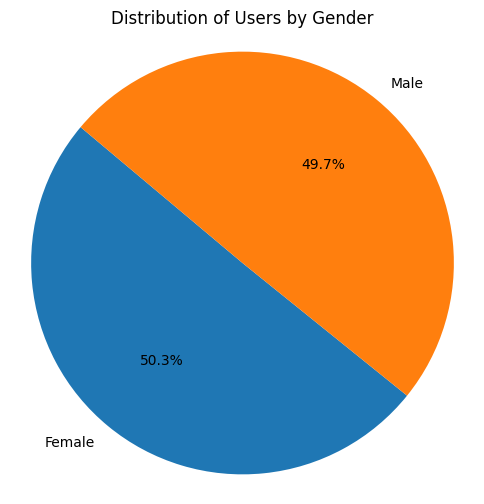


Invoking: `Python_REPL` with `{'query': "import matplotlib.pyplot as plt\n\n# Data\nlabels = ['Female', 'Male']\nsizes = [50312, 49688]\n\n# Plot\nplt.figure(figsize=(6,6))\nplt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)\nplt.axis('equal')\nplt.title('Distribution of Users by Gender')\nplt.show()"}`


Here is the Python code to plot the distribution of users by gender:

```python
import matplotlib.pyplot as plt

# Data
labels = ['Female', 'Male']
sizes = [50312, 49688]

# Plot
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Distribution of Users by Gender')
plt.show()
``` 

This code will create a pie chart showing the distribution of users by gender.

> Finished chain.


In [17]:
sql_query_engine, dashboard_engine = init_engines()
query = "Number of users with their gender"
sql_query_engine_output = sql_query_engine.get_query_data(query)
print(sql_query_engine_output)

dashboard_engine_output = dashboard_engine.get_output(sql_query_engine_output)
dashboard_engine.export_to_streamlit(dashboard_engine_output)

## QUERY 2

- number of users in each country who came via facebook



> Entering new AgentExecutor chain...

Invoking: `sql_db_list_tables` with `{}`


distribution_centers, events, inventory_items, order_items, orders, products, users
Invoking: `sql_db_schema` with `{'table_names': 'users,events'}`



CREATE TABLE events (
	id INTEGER, 
	user_id INTEGER, 
	sequence_number INTEGER, 
	session_id VARCHAR(255), 
	created_at TIMESTAMP, 
	ip_address VARCHAR(255), 
	city VARCHAR(255), 
	state VARCHAR(255), 
	postal_code VARCHAR(255), 
	browser VARCHAR(255), 
	traffic_source VARCHAR(255), 
	uri VARCHAR(255), 
	event_type VARCHAR(255)
)

/*
3 rows from events table:
id	user_id	sequence_number	session_id	created_at	ip_address	city	state	postal_code	browser	traffic_source	uri	event_type
1679667	None	3	ac0caa7c-cb18-4be3-9843-6e19b39e298b	None	33.194.53.72	São Paulo	São Paulo	02675-031	Firefox	Adwords	/cancel	cancel
1405655	None	3	eacfccad-fbe4-4326-b775-2b8d8c30e114	None	46.34.135.113	São Paulo	São Paulo	02675-031	Chrome	Adwords	/cancel	cancel
1902445	None	3	b90

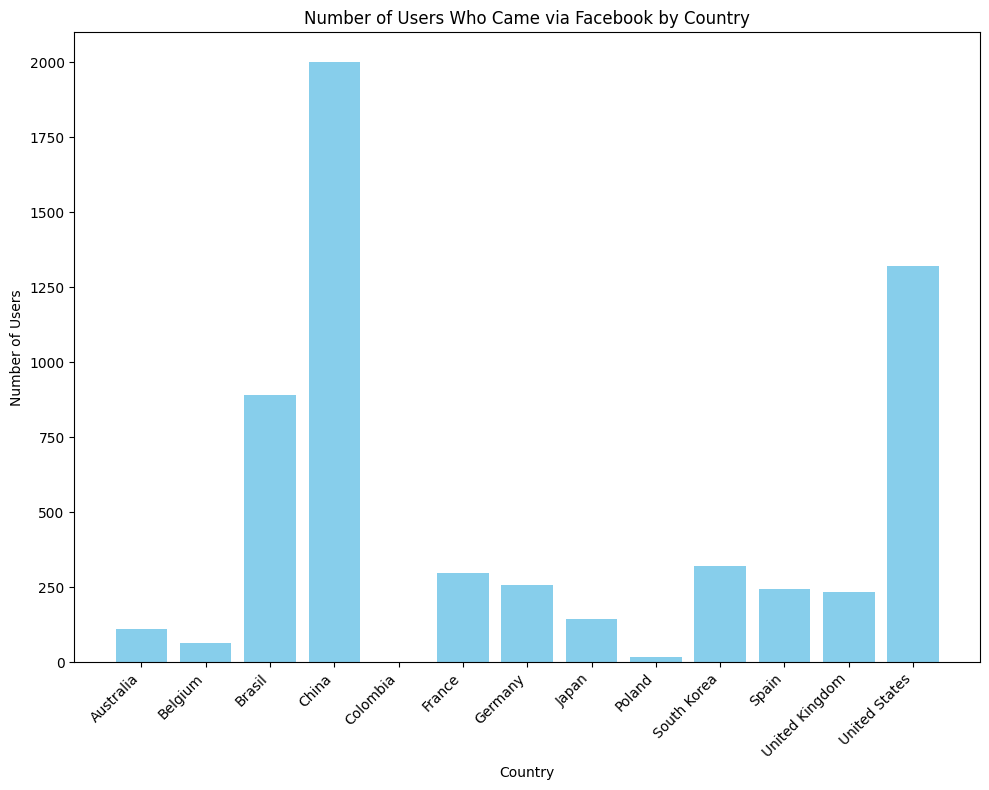

The code to plot the given data is as follows:

```python
import matplotlib.pyplot as plt

# Data
countries = ['Australia', 'Belgium', 'Brasil', 'China', 'Colombia', 'France', 'Germany', 'Japan', 'Poland', 'South Korea', 'Spain', 'United Kingdom', 'United States']
users = [109, 64, 892, 2000, 1, 298, 257, 144, 17, 320, 242, 233, 1321]

# Plotting
plt.figure(figsize=(10, 8))
plt.bar(countries, users, color='skyblue')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.title('Number of Users Who Came via Facebook by Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
```

This code will generate a bar chart displaying the number of users from each country who came via Facebook.

> Finished chain.


In [ ]:
#sql_query_engine, dashboard_engine = init_engines()
query = "number of users in each country who came via facebook"
sql_query_engine_output = sql_query_engine.get_query_data(query)
print(sql_query_engine_output)

dashboard_engine_output = dashboard_engine.get_output(sql_query_engine_output)
dashboard_engine.export_to_streamlit(dashboard_engine_output)

## QUERY 3

- number of orders per month since January 2020

In [ ]:
#sql_query_engine, dashboard_engine = init_engines()
query = "number of users in each country who came via facebook and placed orders since Jan 2020"
sql_query_engine_output = sql_query_engine.get_query_data(query)
#print(sql_query_engine_output)

dashboard_engine_output = dashboard_engine.get_output(sql_query_engine_output)
dashboard_engine.export_to_streamlit(dashboard_engine_output)



> Entering new AgentExecutor chain...

Invoking: `sql_db_list_tables` with `{}`


distribution_centers, events, inventory_items, order_items, orders, products, users
Invoking: `sql_db_schema` with `{'table_names': 'users,orders,events'}`



CREATE TABLE events (
	id INTEGER, 
	user_id INTEGER, 
	sequence_number INTEGER, 
	session_id VARCHAR(255), 
	created_at TIMESTAMP, 
	ip_address VARCHAR(255), 
	city VARCHAR(255), 
	state VARCHAR(255), 
	postal_code VARCHAR(255), 
	browser VARCHAR(255), 
	traffic_source VARCHAR(255), 
	uri VARCHAR(255), 
	event_type VARCHAR(255)
)

/*
3 rows from events table:
id	user_id	sequence_number	session_id	created_at	ip_address	city	state	postal_code	browser	traffic_source	uri	event_type
1679667	None	3	ac0caa7c-cb18-4be3-9843-6e19b39e298b	None	33.194.53.72	São Paulo	São Paulo	02675-031	Firefox	Adwords	/cancel	cancel
1405655	None	3	eacfccad-fbe4-4326-b775-2b8d8c30e114	None	46.34.135.113	São Paulo	São Paulo	02675-031	Chrome	Adwords	/cancel	cancel
1902445	Non

## QUERY 4

- top 3 product categories with highest number of returns by count

In [ ]:
#sql_query_engine, dashboard_engine = init_engines()
query = "top 3 product categories with highest number of returns by count"
sql_query_engine_output = sql_query_engine.get_query_data(query)
#print(sql_query_engine_output)

dashboard_engine_output = dashboard_engine.get_output(sql_query_engine_output)
#dashboard_engine.export_to_streamlit(dashboard_engine_output)



> Entering new AgentExecutor chain...

Invoking: `sql_db_list_tables` with `{}`


distribution_centers, events, inventory_items, order_items, orders, products, users
Invoking: `sql_db_schema` with `{'table_names': 'orders'}`



CREATE TABLE orders (
	order_id INTEGER, 
	user_id INTEGER, 
	status VARCHAR(255), 
	gender VARCHAR(255), 
	created_at TIMESTAMP, 
	returned_at TIMESTAMP, 
	shipped_at TIMESTAMP, 
	delivered_at TIMESTAMP, 
	num_of_item INTEGER
)

/*
3 rows from orders table:
order_id	user_id	status	gender	created_at	returned_at	shipped_at	delivered_at	num_of_item
23	15	Cancelled	F	None	None	None	None	1
45	30	Cancelled	F	None	None	None	None	1
60	40	Cancelled	F	None	None	None	None	4
*/
Invoking: `sql_db_schema` with `{'table_names': 'order_items'}`



CREATE TABLE order_items (
	id INTEGER, 
	order_id INTEGER, 
	user_id INTEGER, 
	product_id INTEGER, 
	inventory_item_id INTEGER, 
	status VARCHAR(255), 
	created_at TIMESTAMP, 
	shipped_at TIMESTAMP, 
	delivered_at TIMESTAMP, 
	re

## QUERY 5

- return percentage country wise

In [ ]:
#sql_query_engine, dashboard_engine = init_engines()
query = "return percentage country wise"
sql_query_engine_output = sql_query_engine.get_query_data(query)
print(sql_query_engine_output)

dashboard_engine_output = dashboard_engine.get_output(sql_query_engine_output)
dashboard_engine.export_to_streamlit(dashboard_engine_output)



> Entering new AgentExecutor chain...

Invoking: `sql_db_list_tables` with `{}`


distribution_centers, events, inventory_items, order_items, orders, products, users
Invoking: `sql_db_schema` with `{'table_names': 'orders,users'}`



CREATE TABLE orders (
	order_id INTEGER, 
	user_id INTEGER, 
	status VARCHAR(255), 
	gender VARCHAR(255), 
	created_at TIMESTAMP, 
	returned_at TIMESTAMP, 
	shipped_at TIMESTAMP, 
	delivered_at TIMESTAMP, 
	num_of_item INTEGER
)

/*
3 rows from orders table:
order_id	user_id	status	gender	created_at	returned_at	shipped_at	delivered_at	num_of_item
23	15	Cancelled	F	None	None	None	None	1
45	30	Cancelled	F	None	None	None	None	1
60	40	Cancelled	F	None	None	None	None	4
*/


CREATE TABLE users (
	id INTEGER, 
	first_name VARCHAR(255), 
	last_name VARCHAR(255), 
	email VARCHAR(255), 
	age INTEGER, 
	gender VARCHAR(255), 
	state VARCHAR(255), 
	street_address VARCHAR(255), 
	postal_code VARCHAR(255), 
	city VARCHAR(255), 
	country VARCHAR(255), 
	latitude FLOAT,

## QUERY 6

- which are my top 5 geographies with highest business



> Entering new AgentExecutor chain...

Invoking: `sql_db_list_tables` with `{}`


distribution_centers, events, inventory_items, order_items, orders, products, users
Invoking: `sql_db_schema` with `{'table_names': 'orders'}`



CREATE TABLE orders (
	order_id INTEGER, 
	user_id INTEGER, 
	status VARCHAR(255), 
	gender VARCHAR(255), 
	created_at TIMESTAMP, 
	returned_at TIMESTAMP, 
	shipped_at TIMESTAMP, 
	delivered_at TIMESTAMP, 
	num_of_item INTEGER
)

/*
3 rows from orders table:
order_id	user_id	status	gender	created_at	returned_at	shipped_at	delivered_at	num_of_item
23	15	Cancelled	F	None	None	None	None	1
45	30	Cancelled	F	None	None	None	None	1
60	40	Cancelled	F	None	None	None	None	4
*/
Invoking: `sql_db_schema` with `{'table_names': 'users'}`



CREATE TABLE users (
	id INTEGER, 
	first_name VARCHAR(255), 
	last_name VARCHAR(255), 
	email VARCHAR(255), 
	age INTEGER, 
	gender VARCHAR(255), 
	state VARCHAR(255), 
	street_address VARCHAR(255), 
	postal_code VARCHAR(255), 
	city VA

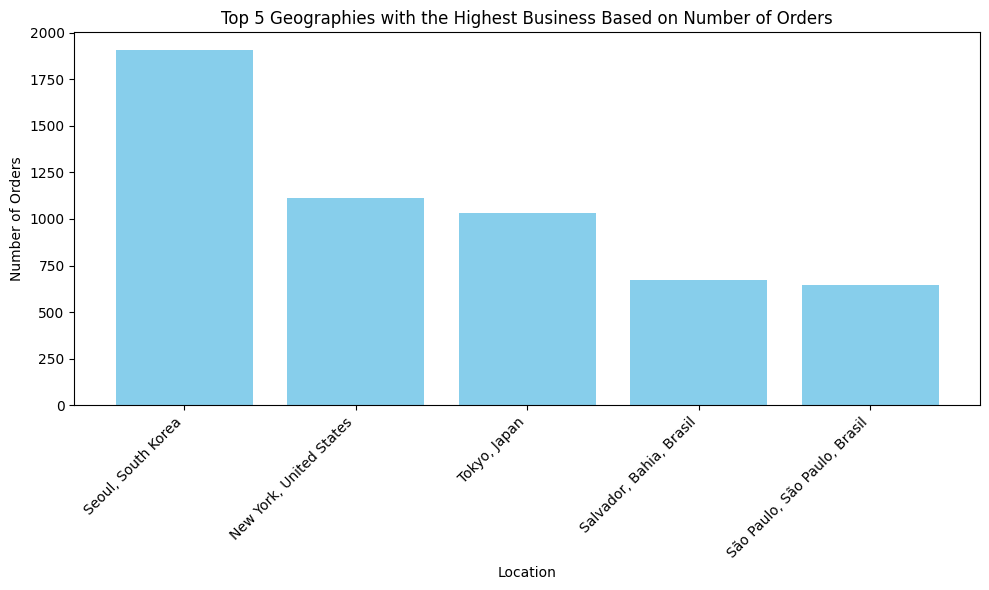

The code to plot the data for the top 5 geographies with the highest business based on the number of orders is as follows:

```python
import matplotlib.pyplot as plt

# Data
locations = ['Seoul, South Korea', 'New York, United States', 'Tokyo, Japan', 'Salvador, Bahia, Brasil', 'São Paulo, São Paulo, Brasil']
orders = [1907, 1115, 1030, 673, 644]

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(locations, orders, color='skyblue')
plt.title('Top 5 Geographies with the Highest Business Based on Number of Orders')
plt.xlabel('Location')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
```

This code will generate a bar chart displaying the number of orders for each of the top 5 locations.

> Finished chain.


In [ ]:
#sql_query_engine, dashboard_engine = init_engines()
query = "which are my top 5 geographies with highest business"
sql_query_engine_output = sql_query_engine.get_query_data(query)
#print(sql_query_engine_output)

dashboard_engine_output = dashboard_engine.get_output(sql_query_engine_output)
dashboard_engine.export_to_streamlit(dashboard_engine_output)

## QUERY 7

- which product categories have the highest margins in 2024

In [ ]:
#sql_query_engine, dashboard_engine = init_engines()
query = "which product categories have the highest margins in 2024"
sql_query_engine_output = sql_query_engine.get_query_data(query)
#print(sql_query_engine_output)

dashboard_engine_output = dashboard_engine.get_output(sql_query_engine_output)
dashboard_engine.export_to_streamlit(dashboard_engine_output)



> Entering new AgentExecutor chain...

Invoking: `sql_db_list_tables` with `{}`


distribution_centers, events, inventory_items, order_items, orders, products, users
Invoking: `sql_db_schema` with `{'table_names': 'products,order_items'}`



CREATE TABLE order_items (
	id INTEGER, 
	order_id INTEGER, 
	user_id INTEGER, 
	product_id INTEGER, 
	inventory_item_id INTEGER, 
	status VARCHAR(255), 
	created_at TIMESTAMP, 
	shipped_at TIMESTAMP, 
	delivered_at TIMESTAMP, 
	returned_at TIMESTAMP, 
	sale_price FLOAT
)

/*
3 rows from order_items table:
id	order_id	user_id	product_id	inventory_item_id	status	created_at	shipped_at	delivered_at	returned_at	sale_price
162569	112164	89224	14235	438986	Cancelled	None	None	None	None	0.0199999995529651
25143	17365	13804	14235	67816	Complete	None	None	None	None	0.0199999995529651
162494	112111	89185	14235	438784	Complete	None	None	None	None	0.0199999995529651
*/


CREATE TABLE products (
	id INTEGER, 
	cost FLOAT, 
	category VARCHAR(255), 
	name VARCH